<a href="https://colab.research.google.com/github/zhaoboan0215-sys/MLprojrct/blob/bert/ML_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from sklearn.metrics import accuracy_score, f1_score, recall_score, confusion_matrix
from transformers import BertTokenizer, TFBertForSequenceClassification
import tf_keras as keras
from tensorflow.keras.callbacks import ReduceLROnPlateau
import matplotlib.pyplot as plt
import tensorflow as tf

In [4]:
train_df = pd.read_csv("train.csv")   # tweet_id, text, emotions
test_df  = pd.read_csv("test.csv")    # tweet_id, text

print(train_df.head())
print(train_df["emotions"].value_counts())
train_df, valid_df = train_test_split(
    train_df,
    test_size=0.1,
    random_state=42,
    stratify=train_df["emotions"],
)

len(train_df), len(valid_df)
model_name = "bert-base-uncased"
tokenizer = BertTokenizer.from_pretrained(model_name)
max_len = 128
num_labels = 6

   tweet_id                                               text  emotions
0         0  i will feel stronger and more sincere in this ...         1
1         1                        i feel oh so glamourous set         1
2         2  i just didn t feel a strong push to spend time...         1
3         3  i feel like in the past this dream has given m...         0
4         4              i had trouble feeling satisfied today         1
emotions
1    130914
0    112464
3     53192
4     44278
2     32067
5     13894
Name: count, dtype: int64


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

In [5]:
def encode_examples(df, tokenizer, max_len=128, is_training=True):
    texts = df["text"].tolist()
    encodings = tokenizer(
        texts,
        padding="max_length",
        truncation=True,
        max_length=max_len,
        return_tensors="tf",
    )
    if is_training:
        labels = df["emotions"].values
        dataset = tf.data.Dataset.from_tensor_slices((
            dict(encodings),
            labels
        ))
    else:
        dataset = tf.data.Dataset.from_tensor_slices(dict(encodings))
    return dataset


In [9]:
batch_size = 32

train_ds = encode_examples(train_df, tokenizer, max_len, is_training=True).shuffle(10000).batch(batch_size)
valid_ds = encode_examples(valid_df, tokenizer, max_len, is_training=True).batch(batch_size)
test_ds  = encode_examples(test_df, tokenizer, max_len, is_training=False).batch(batch_size)


In [10]:

model = TFBertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=num_labels,
    from_pt=True,
)
loss_fn = SparseCategoricalCrossentropy(from_logits=True)
optimizer = keras.optimizers.Adam(learning_rate=1e-5)
model.compile(
    optimizer=optimizer,
    loss=loss_fn,
    metrics=["accuracy"],
)
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=1,
    min_lr=1e-6,
    verbose=1
)


All PyTorch model weights were used when initializing TFBertForSequenceClassification.

Some weights or buffers of the TF 2.0 model TFBertForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['classifier.weight', 'classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


train the model

In [11]:
history = model.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=8,
    #callbacks=[reduce_lr],
)


Epoch 1/8
10879/10879 [==============================] - 1098s 96ms/step - loss: 0.1466 - accuracy: 0.9267 - val_loss: 0.0877 - val_accuracy: 0.9418
Epoch 2/8
10879/10879 [==============================] - 1015s 93ms/step - loss: 0.0881 - accuracy: 0.9426 - val_loss: 0.0856 - val_accuracy: 0.9435
Epoch 3/8
10879/10879 [==============================] - 1013s 93ms/step - loss: 0.0837 - accuracy: 0.9439 - val_loss: 0.0881 - val_accuracy: 0.9442
Epoch 4/8
10879/10879 [==============================] - 1016s 93ms/step - loss: 0.0815 - accuracy: 0.9447 - val_loss: 0.0886 - val_accuracy: 0.9427
Epoch 5/8
10879/10879 [==============================] - 1016s 93ms/step - loss: 0.0802 - accuracy: 0.9446 - val_loss: 0.0911 - val_accuracy: 0.9438
Epoch 6/8
10879/10879 [==============================] - 1021s 94ms/step - loss: 0.0793 - accuracy: 0.9449 - val_loss: 0.0933 - val_accuracy: 0.9420
Epoch 7/8
10879/10879 [==============================] - 1023s 94ms/step - loss: 0.0787 - accuracy: 0.9455

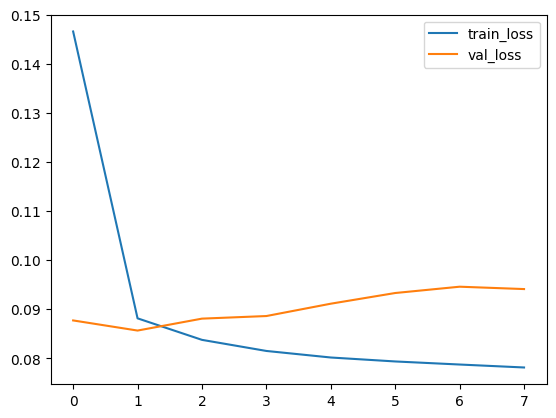

In [19]:
plt.plot(history.history["loss"], label="train_loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.legend()
plt.show()


In [21]:
valid_logits = model.predict(valid_ds).logits
valid_pred = np.argmax(valid_logits, axis=-1)

valid_true = valid_df["emotions"].values

macro_f1 = f1_score(valid_true, valid_pred, average="macro")
acc      = accuracy_score(valid_true, valid_pred)

print("Validation accuracy:", acc)
print("Validation macro F1:", macro_f1)


1209/1209 [==============================] - 47s 36ms/step
Validation accuracy: 0.9436932861094595
Validation macro F1: 0.9194212275735171


In [22]:
cm = confusion_matrix(valid_true, valid_pred)
print(cm)


[[10761     4     0   270   211     0]
 [    5 12059   899     5     6   118]
 [    0     3  3204     0     0     0]
 [   10    11     1  5062   235     0]
 [    6    10     0    23  4037   352]
 [    8     0     0     0     1  1380]]


In [23]:
test_logits = model.predict(test_ds).logits
test_pred   = np.argmax(test_logits, axis=-1)

submission = pd.DataFrame({
    "id": test_df["tweet_id"],
    "label": test_pred,
})

submission.head()


938/938 [==============================] - 34s 36ms/step


,id,label
0,0,1
1,1,1
2,2,0
3,3,5
4,4,0


In [24]:
submission.to_csv("submission.csv", index=False)
print("Saved submission.csv")


Saved submission.csv
